<a href="https://colab.research.google.com/github/eyluelo/dashboard-tutorials/blob/main/Kopie_von_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Superstore Sales Dashboard

## Project Overview

This notebook analyzes sales data from a US retail company (2014-2017).
It provides key business insights through visualizations.

## Dataset

- Source: Kaggle - Superstore Dataset
- Rows: 9,994 | Columns: 21
- Period: 2014-2017

## Key Questions

1. Which product category generates the most sales?
2. How has revenue trended over the years?
3. Which region is most profitable?

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d vivek468/superstore-dataset-final

Dataset URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
License(s): other
superstore-dataset-final.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
with zipfile.ZipFile('/content/superstore-dataset-final.zip','r') as zip_ref:
  zip_ref.extractall('/content')

In [ ]:
import os

os.listdir("/content")

['.config',
 'Sample - Superstore.csv',
 'superstore-dataset-final.zip',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Sample - Superstore.csv", encoding = "latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [ ]:
df[['Sales', 'Profit', 'Category', 'Region']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


In [ ]:
total_sales = df['Sales'].sum()
print(f"Total Sales: {total_sales}")

total_profit = df['Profit'].sum()
print(f"Total Profit: {total_profit}")

total_quantity = df['Quantity'].sum()
print(f"Total Quantity: {total_quantity}")

total_discount = df['Discount'].sum()
print(f"Total Discount: {total_discount}")

total_orders = df['Order ID'].nunique()
print(f"Total Orders: {total_orders}")

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Quantity: 37873
Total Discount: 1561.09
Total Orders: 5009


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


## Chart 1: Sales by Category

This chart shows total revenue broken down by product category.

**Insight:** Technology leads with $836K in sales.

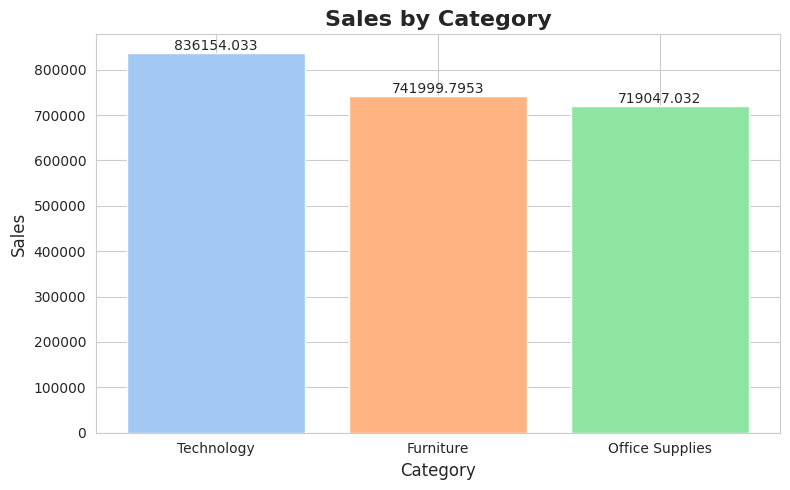

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#set style
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize = (8, 5))

colors = sns.color_palette('pastel')[0:5]

ax.bar(category_sales.index, category_sales.values, color= colors)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Sales',fontsize=12)
ax.set_title('Sales by Category', fontsize = 16, fontweight= 'bold')

for i, v in enumerate(category_sales.values):
  ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
print(df['Year'].value_counts().sort_index())

Year
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64


In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum()
print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


## Chart 2: Yearly Sales Trend (2014-2017)

This chart shows how total sales evolved over four years.

**Insight:** Sales dipped in 2015 but recovered strongly, growing 51% from 2014 to 2017.

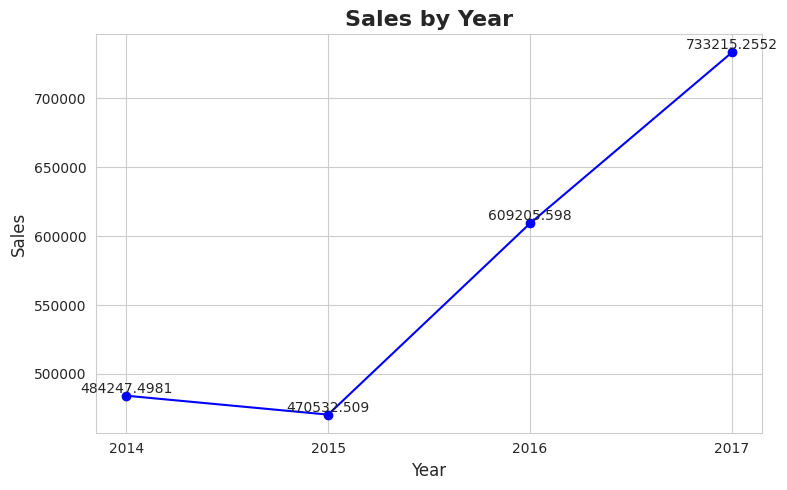

In [ ]:
fig, ax = plt.subplots(figsize = (8, 5))

ax.plot(yearly_sales.index, yearly_sales.values, marker='o', linestyle='-', color='b')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sales',fontsize=12)
ax.set_title('Sales by Year', fontsize = 16, fontweight= 'bold')

for x, y in zip(yearly_sales.index, yearly_sales.values):
  ax.text(x, y, str(y), ha='center', va='bottom', fontsize=10)

ax.set_xticks([2014, 2015, 2016, 2017])

plt.tight_layout()
plt.show()

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


## Chart 3: Profit by Region

This chart compares profitability across the four US regions.

**Insight:** West is the most profitable region with $108K.

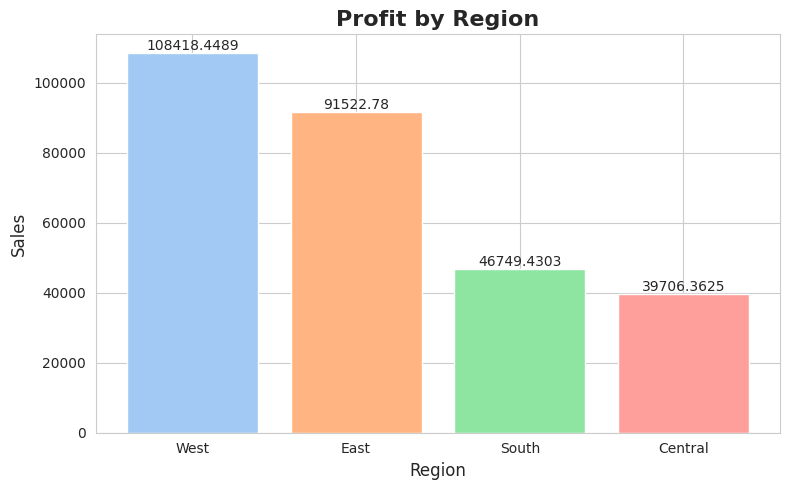

In [ ]:
fig, ax = plt.subplots(figsize = (8, 5))

ax.bar(region_profit.index, region_profit.values, color=sns.color_palette('pastel')[0:5])
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Sales',fontsize=12)
ax.set_title('Profit by Region', fontsize = 16, fontweight= 'bold')

for x, y in zip(region_profit.index, region_profit.values):
  ax.text(x, y, str(y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## KPI Summary Dashboard

A high-level overview of the most important business metrics.

**Insight:** The company generated $2.3M in revenue with a profit margin of ~12.5%

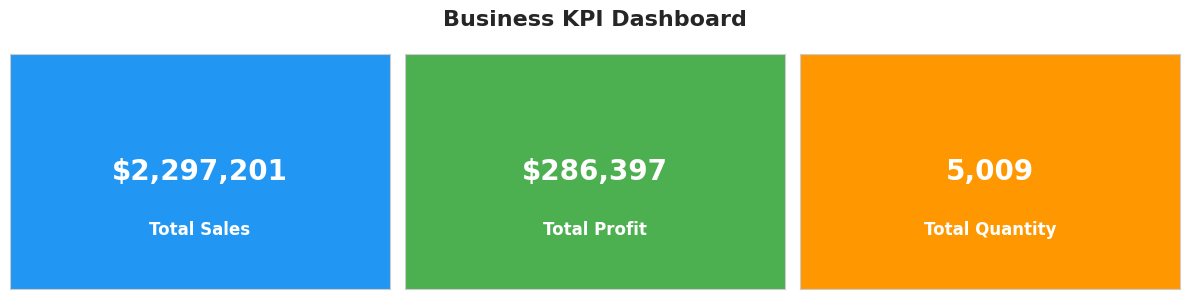

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

kpis = [
    ('Total Sales',f'${total_sales:,.0f}', '#2196F3'),
    ('Total Profit', f'${total_profit:,.0f}','#4CAF50'),
    ('Total Quantity', f'{total_orders:,}','#FF9800') ]

for ax, (title, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.5, str(value), ha='center', va='center', fontsize=20, fontweight='bold', color= 'white', transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center', fontsize=12, fontweight='bold', color= 'white', transform=ax.transAxes)

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Business KPI Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()